In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso

In [2]:
# Исходные данные
data = pd.DataFrame({
    'ξ': [1, 0, 1],
    'η': [0, 1, 1],
    'ω': [1, 5, 2]
})

In [3]:
# a) Найти уравнение линейной регрессии
PSI = data.drop('ω', axis=1)
Y = data.ω

model = sm.OLS(Y, PSI).fit()

print("Коэффициенты линейной регрессии:")
print(model.params)

Коэффициенты линейной регрессии:
ξ   -0.333333
η    3.666667
dtype: float64


In [4]:
# b) Найти уравнение ridge регрессии и определить значение параметра регуляризации

def alpha(i: int):
    return 10 * (i + 1) / N

N = 10000
CVSS = np.zeros(N)

# Кросс-валидация
for i in range(N):
    for j in range(3):
        ridge = Ridge(alpha=alpha(i), fit_intercept=False, max_iter=10000).fit(PSI.drop(j), Y.drop(j))
        CVSS[i] += (Y.loc[j] - np.dot(ridge.coef_, PSI.loc[j])) ** 2

min_index = np.argmin(CVSS)
alpha_opt = alpha(min_index)
print(f'α_opt: {alpha_opt:.4f}')

ridge_opt = Ridge(alpha=alpha_opt, fit_intercept=False, max_iter=10000).fit(PSI, Y)
print("Коэффициенты Ridge:", ridge_opt.coef_)

α_opt: 1.5060
Коэффициенты Ridge: [0.31154701 1.9077162 ]


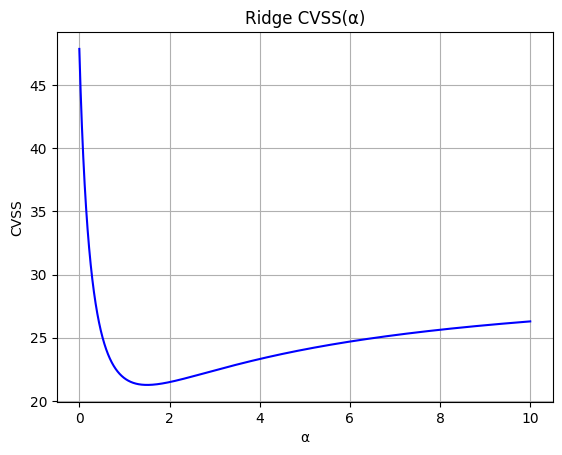

In [5]:
plt.plot(np.linspace(0, 10, N), CVSS, color='b')

plt.xlabel('α')
plt.ylabel('CVSS')
plt.title('Ridge CVSS(α)')
plt.grid(True)
plt.show()

In [6]:
# c) Найти уравнение lasso регрессии и определить значение параметра регуляризации

CVSS = np.zeros(N)

# Кросс-валидация LOOCV
for i in range(N):
    for j in range(3):
        lasso = Lasso(alpha=alpha(i), fit_intercept=False, max_iter=10000).fit(PSI.drop(j), Y.drop(j))
        CVSS[i] += (Y.loc[j] - np.dot(lasso.coef_, PSI.loc[j])) ** 2

# Находим оптимальный альфа на кросс-валидации
min_index = np.argmin(CVSS)
alpha_opt_cv = alpha(min_index)
print(f'α_opt (по кросс-валидации, n=2): {alpha_opt_cv:.4f}')

# Обучаем итоговую модель с правильным параметром
lasso_opt = Lasso(alpha=alpha_opt_cv, fit_intercept=False, max_iter=10000).fit(PSI, Y)
print("Коэффициенты Lasso:", lasso_opt.coef_)

α_opt (по кросс-валидации, n=2): 1.5000
Коэффициенты Lasso: [0.   1.25]


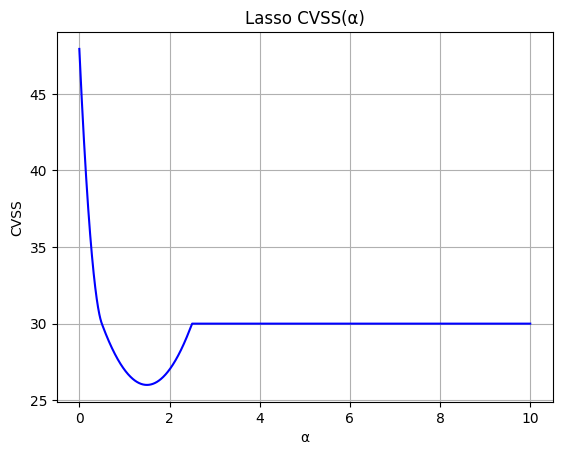

In [7]:
plt.plot(np.linspace(0, 10, N), CVSS, color='b')

plt.xlabel('α')
plt.ylabel('CVSS')
plt.title('Lasso CVSS(α)')
plt.grid(True)
plt.show()

α_opt (по кросс-валидации): 5.9697


<Figure size 1000x600 with 0 Axes>

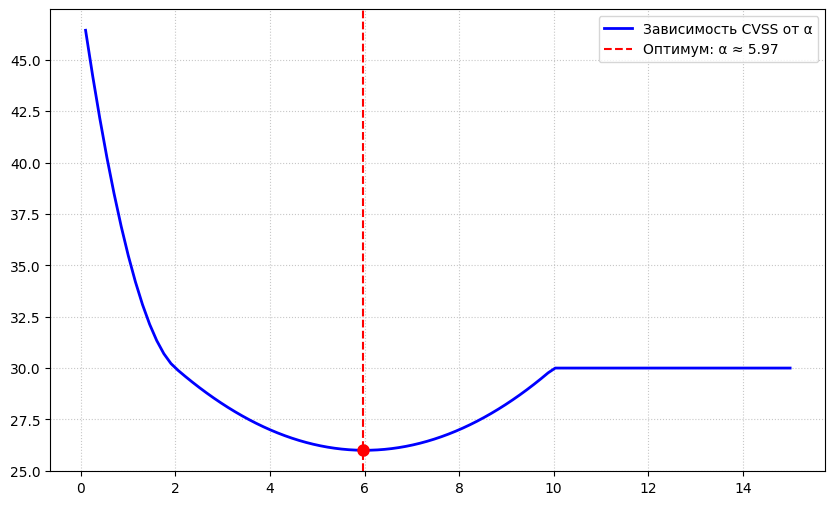

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

N = len(Y)

alphas = np.linspace(0.1, 15, 100)
CVSS = np.zeros(len(alphas))

for idx, a in enumerate(alphas):
    current_cvss = 0
    
    for i in range(N):
        PSI_train = PSI.drop(index=PSI.index[i])
        Y_train = Y.drop(index=Y.index[i])
        PSI_test = PSI.iloc[i]
        Y_test = Y.iloc[i]  

        a_corrected = a / (2 * (N - 1))
        
        lasso = Lasso(alpha=a_corrected, fit_intercept=False, max_iter=10000).fit(PSI_train, Y_train)
        
        prediction = np.dot(lasso.coef_, PSI_test)
        current_cvss += (Y_test - prediction) ** 2
        
    CVSS[idx] = current_cvss

min_index = np.argmin(CVSS)
alpha_opt_cv = alphas[min_index]
min_cvss = CVSS[min_index]

print(f'α_opt (по кросс-валидации): {alpha_opt_cv:.4f}')

plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))
plt.plot(alphas, CVSS, label='Зависимость CVSS от α', color='blue', linewidth=2)
plt.axvline(x=alpha_opt_cv, color='red', linestyle='--', label=f'Оптимум: α ≈ {alpha_opt_cv:.2f}')
plt.plot(alpha_opt_cv, min_cvss, 'ro', markersize=8)
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()